# Week 1 - Exploratory Data Analysis on MS MARCO

This notebook presents an initial exploratory data analysis of the MS MARCO dataset. The goal is to understand the overall structure of the dataset through several descriptive statistics, including query length, passage length, frequent query terms, answer patterns, and query type distribution.

At this stage, the analysis mainly focuses on a high-level overview of the training split. Additional query-type-specific comparisons are included to examine whether different query categories show different characteristics.

## 1. Environment Setup

First, we import the required libraries and verify that the environment is ready for analysis.

In [13]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

print("Torch version:", torch.__version__)
print("Environment OK")

Torch version: 2.10.0+cpu
Environment OK


## 2. Dataset Loading

We load the MS MARCO dataset (version 2.1) from Hugging Face Datasets and inspect its available splits and features.

In [14]:
dataset = load_dataset("ms_marco", "v2.1")

In [15]:
dataset

DatasetDict({
    validation: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 101093
    })
    train: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 808731
    })
    test: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 101092
    })
})

In [16]:
dataset["train"][0]

{'answers': ['The immediate impact of the success of the manhattan project was the only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.'],
 'passages': {'is_selected': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  'passage_text': ['The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.',
   'The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science.',
   'Essay on The Manhattan Project - The Manhattan Project The Manhattan Project was to see if making an atomic bomb possible. The success of th

### Observation

The dataset contains three splits: training, validation, and test.  
Each example includes the following main fields:

- `query`: the user question
- `passages`: candidate passages associated with the query
- `answers`: answer annotations
- `query_type`: query category
- `wellFormedAnswers`: well-formed answer annotations when available

This confirms that `query_type` is explicitly available and can be analyzed as part of the EDA.

## 3. Query Length Distribution

To understand how users formulate questions, we examine the distribution of query lengths in a random sample of 5,000 training queries. Query length is measured by the number of whitespace-separated words.

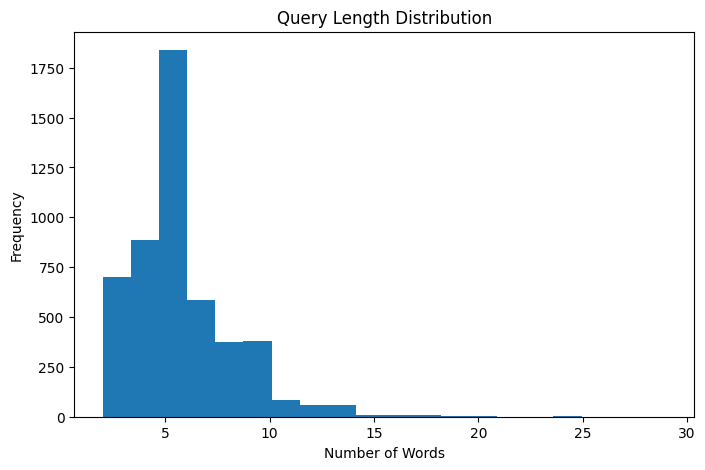

In [17]:
queries = [x["query"] for x in dataset["train"].select(range(5000))]
query_lengths = [len(q.split()) for q in queries]

plt.figure(figsize=(8, 5))
plt.hist(query_lengths, bins=20)
plt.title("Query Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig("../reports/query_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Most queries are relatively short, suggesting that information needs are often expressed concisely. This is consistent with the search-oriented nature of the MS MARCO dataset.

### Note

This result is based on a random sample of 5,000 queries from the training split.

## 4. Passage Length Distribution

Next, we analyze the length distribution of candidate passages. For efficiency, we use 2,000 sampled training queries and collect their associated passage texts. Passage length is measured by the number of whitespace-separated words.

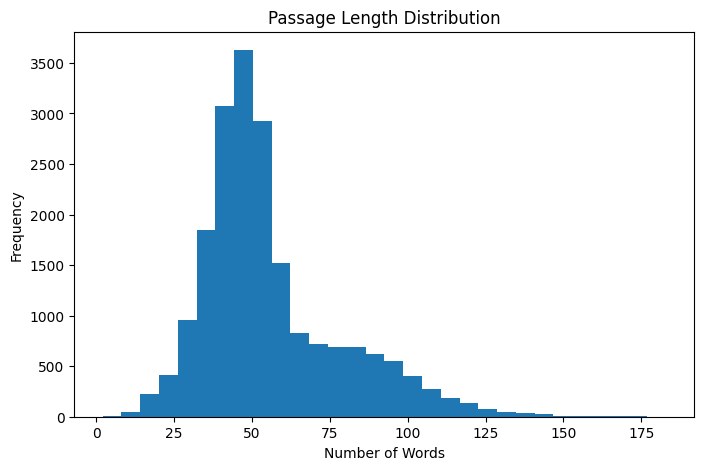

In [18]:
passages = []

sample = dataset["train"].select(range(2000))

for x in sample:
    for p in x["passages"]["passage_text"]:
        passages.append(p)

lengths = [len(p.split()) for p in passages]

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30)
plt.title("Passage Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.savefig("../reports/passage_length_distribution.png", dpi=300)
plt.show()

### Observation

Passage lengths are noticeably longer than query lengths, which is expected because passages contain contextual information intended to support answer retrieval.

### Note

This passage-level analysis is based on passages associated with 2,000 sampled training queries.

## 5. Frequent Query Terms

To get a rough sense of the linguistic patterns in user queries, we count the most frequent words appearing in a random sample of 5,000 training queries.

In [19]:
from collections import Counter

queries = [x["query"] for x in dataset["train"].select(range(5000))]

words = []

for q in queries:
    words.extend(q.lower().split())

counter = Counter(words)

counter.most_common(20)

[('what', 1847),
 ('is', 1455),
 ('a', 914),
 ('how', 723),
 ('in', 722),
 ('of', 702),
 ('the', 648),
 ('to', 584),
 ('does', 428),
 ('for', 383),
 ('are', 336),
 ('definition', 259),
 ('do', 239),
 ('can', 156),
 ('and', 153),
 ('on', 153),
 ('cost', 143),
 ('number', 142),
 ('county', 142),
 ('an', 136)]

### Observation

Common question words such as "what", "is", "how", and "does" appear frequently, indicating that the dataset contains many natural-language factoid and definition-style queries.

### Note

This is a surface-level frequency analysis and does not remove stopwords, so the results mainly reflect broad query-writing patterns rather than topic-specific keywords.

## 6. Answer Type Distribution

We perform a simple rule-based categorization of answers into three coarse groups:

- short answers
- sentence-like answers
- numeric answers

This provides a rough overview of the response formats found in the dataset.

In [20]:
answers = [x["answers"][0] if len(x["answers"])>0 else "" 
           for x in dataset["train"].select(range(5000))]

short = 0
sentence = 0
numeric = 0

for a in answers:
    if any(char.isdigit() for char in a):
        numeric += 1
    elif len(a.split()) <= 3:
        short += 1
    else:
        sentence += 1

print("Short answers:", short)
print("Sentence answers:", sentence)
print("Numeric answers:", numeric)

Short answers: 2462
Sentence answers: 1669
Numeric answers: 869


### Observation

Short answers appear most frequently in the sampled data, while sentence-like and numeric answers are also common. This suggests that the dataset contains a mixture of concise factoid responses and longer explanatory answers.

### Note

The categorization here is heuristic rather than annotation-based, so it should be interpreted as an approximate descriptive summary.

## 7. Query Type Analysis

To address potential concerns about distributional differences across query categories,
we extend the initial EDA by analyzing statistics grouped by query_type.  
Since the dataset explicitly includes a `query_type` field, it is useful to examine its distribution and compare several properties across query categories. This helps determine whether different query types exhibit different patterns in terms of query length, answer format, and the number of associated passages.

In [22]:
sample_q = dataset["train"].select(range(5000))

query_types = [x["query_type"] for x in sample_q]
qt_counts = pd.Series(query_types).value_counts()

print(qt_counts)

DESCRIPTION    3035
NUMERIC        1121
ENTITY          445
LOCATION        247
PERSON          152
Name: count, dtype: int64


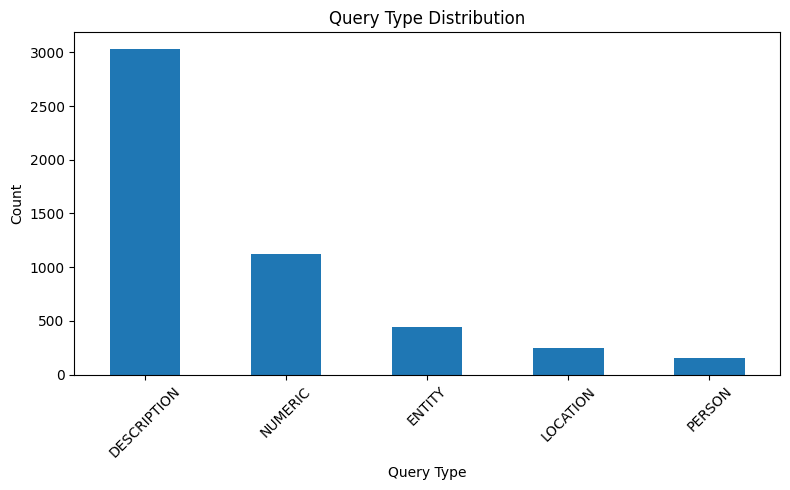

In [23]:
plt.figure(figsize=(8, 5))
qt_counts.plot(kind="bar")
plt.title("Query Type Distribution")
plt.xlabel("Query Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/query_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The query types are not necessarily evenly distributed in the sampled data. If some query categories are much more frequent than others, overall descriptive statistics may be dominated by those categories.

### Implication

This means that conclusions drawn from the current random sample should be interpreted with caution, especially when discussing general patterns across all query types.

In [24]:
df_q = pd.DataFrame({
    "query": [x["query"] for x in sample_q],
    "query_type": [x["query_type"] for x in sample_q],
})

df_q["query_len"] = df_q["query"].apply(lambda x: len(x.split()))

df_q.groupby("query_type")["query_len"].describe()

,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
DESCRIPTION,3035.0,5.696540,2.601753,2.0,4.0,5.0,7.0,29.0
ENTITY,445.0,5.896629,2.332325,2.0,4.0,6.0,7.0,23.0
LOCATION,247.0,5.724696,1.491547,2.0,5.0,6.0,6.0,14.0
NUMERIC,1121.0,6.317574,2.520088,2.0,4.0,6.0,8.0,18.0
PERSON,152.0,5.500000,2.074762,2.0,4.0,5.0,7.0,13.0


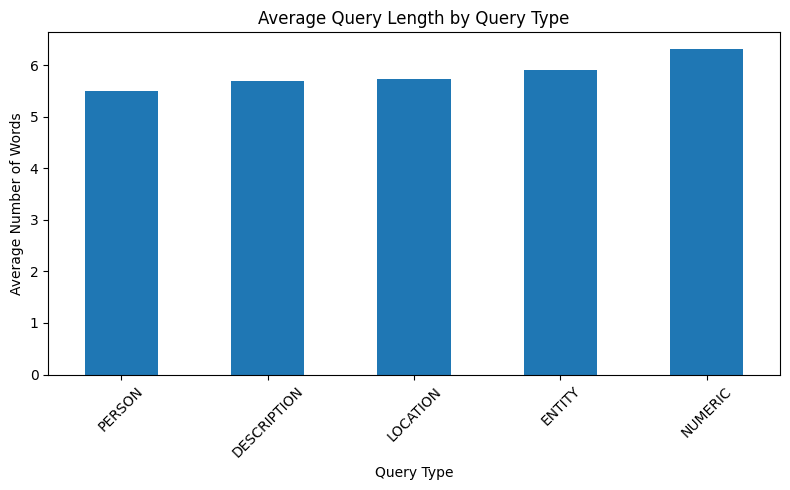

In [25]:
qt_query_len = df_q.groupby("query_type")["query_len"].mean().sort_values()

plt.figure(figsize=(8, 5))
qt_query_len.plot(kind="bar")
plt.title("Average Query Length by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/query_length_by_query_type.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Different query types may have different average query lengths. This suggests that users phrase different categories of information needs in systematically different ways.

### Implication

Query-type-aware analysis may provide a more accurate picture of dataset structure than a purely overall summary.

In [26]:
def get_answer_text(x):
    return x["answers"][0] if len(x["answers"]) > 0 else ""

def classify_answer(a):
    if any(char.isdigit() for char in a):
        return "numeric"
    elif len(a.split()) <= 3:
        return "short"
    else:
        return "sentence"

df_ans = pd.DataFrame({
    "query_type": [x["query_type"] for x in sample_q],
    "answer": [get_answer_text(x) for x in sample_q]
})

df_ans["answer_type"] = df_ans["answer"].apply(classify_answer)

pd.crosstab(df_ans["query_type"], df_ans["answer_type"])

answer_type,numeric,sentence,short
query_type,,,
DESCRIPTION,222,1344,1469
ENTITY,50,156,239
LOCATION,12,75,160
NUMERIC,574,37,510
PERSON,11,57,84


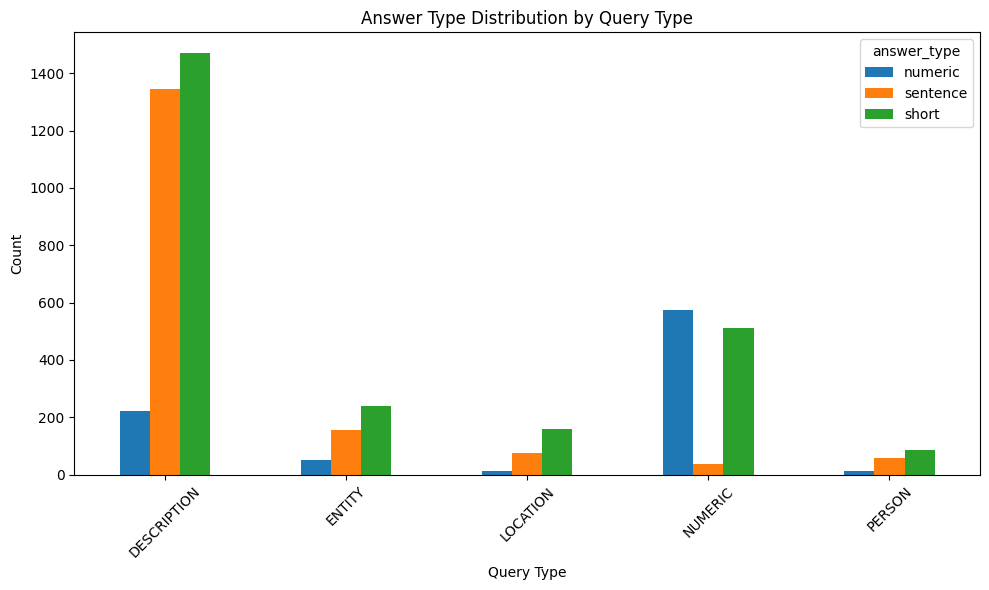

In [27]:
ans_ct = pd.crosstab(df_ans["query_type"], df_ans["answer_type"])

ans_ct.plot(kind="bar", figsize=(10, 6))
plt.title("Answer Type Distribution by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/answer_type_by_query_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
dataset["train"][0]["passages"]

{'is_selected': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'passage_text': ['The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.',
  'The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science.',
  'Essay on The Manhattan Project - The Manhattan Project The Manhattan Project was to see if making an atomic bomb possible. The success of this project would forever change the world forever making it known that something this powerful can be manmade.',
  'The Manhattan Project was the name for a project conducted during World War II, to develop the first atomic bomb. It refers specifically to the period of the project

In [29]:
def count_relevant_passages(x):
    return sum(x["passages"]["is_selected"])

df_passage = pd.DataFrame({
    "query_type": [x["query_type"] for x in sample_q],
    "relevant_passages": [count_relevant_passages(x) for x in sample_q]
})

df_passage.groupby("query_type")["relevant_passages"].describe()

,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
DESCRIPTION,3035.0,0.636903,0.572343,0.0,0.0,1.0,1.0,5.0
ENTITY,445.0,0.683146,0.661563,0.0,0.0,1.0,1.0,4.0
LOCATION,247.0,0.882591,0.449006,0.0,1.0,1.0,1.0,3.0
NUMERIC,1121.0,0.594112,0.539776,0.0,0.0,1.0,1.0,3.0
PERSON,152.0,0.625000,0.617756,0.0,0.0,1.0,1.0,4.0


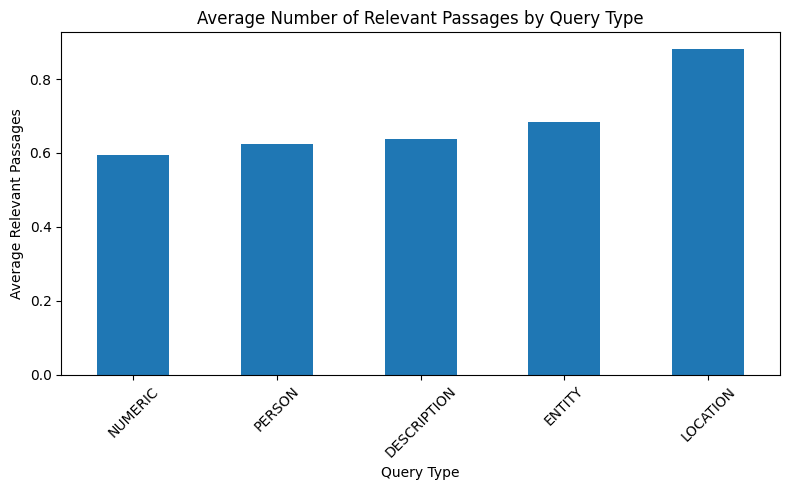

In [30]:
avg_passages = df_passage.groupby("query_type")["relevant_passages"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_passages.plot(kind="bar")
plt.title("Average Number of Relevant Passages by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Average Relevant Passages")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/relevant_passages_by_query_type.png", dpi=300)
plt.show()

### Observation

Across different query types, the average number of relevant passages per query is relatively small and generally close to one. This indicates that most queries in the dataset have only a limited number of passages explicitly marked as relevant.

Location queries show a slightly higher average number of relevant passages compared to other categories. This may reflect the fact that location-based questions often have clearer supporting contexts in the retrieved passages.

### Implication

Overall, the relatively small number of relevant passages suggests that the retrieval component must be effective at identifying a small subset of useful passages among many candidates.

## 8. Sampling Strategy and Limitations

The current Week 1 EDA is based on random samples from the training split:

- 5,000 queries for query-level analysis
- 2,000 queries and their associated passages for passage-level analysis

This sampling strategy was chosen to quickly obtain an initial understanding of the dataset structure. However, the sampling was not stratified by `query_type`. As a result, if some query types are overrepresented, the overall statistics may not fully reflect the characteristics of less frequent categories.

Therefore, the current findings should be viewed as an initial descriptive overview rather than a fully query-type-balanced analysis. A stratified sampling strategy could be adopted in future iterations if stronger generalizability is required.